# 02. Portfolio Optimization: Mean-Variance Framework
Implementation of Modern Portfolio Theory (MPT) to derive optimal asset allocation vectors.
The analysis focuses on the Maximum Sharpe Ratio and Minimum Variance portfolios as boundary solutions for efficient capital allocation.

In [1]:
import sys; sys.path.insert(0, '..')
import logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

import pandas as pd
import numpy as np
from dotenv import load_dotenv
load_dotenv()

from src.data.fetcher import StockDataFetcher
from src.portfolio.optimizer import EfficientFrontier
from src.portfolio.metrics import (
    TRADING_DAYS_PER_YEAR, RISK_FREE_RATE_ANNUAL, DEFAULT_TICKERS,
    DEFAULT_START_DATE, DEFAULT_END_DATE, portfolio_var, portfolio_cvar
)
from src.visualization.plots import (
    plot_efficient_frontier, plot_weights_bar
)

SEED = 42
np.random.seed(SEED)
import random
random.seed(SEED)

# Load Data
fetcher = StockDataFetcher(DEFAULT_TICKERS, DEFAULT_START_DATE, DEFAULT_END_DATE)
prices = fetcher.fetch()
log_returns = fetcher.to_log_returns(prices)

INFO: Loading from cache: data/cache/4c9b5bec659c75c231b2df3b19a3bf90.csv


## 1. Theory: Markowitz Portfolio Optimization

**Portfolio Return:**  E[R_p] = Σᵢ wᵢ · μᵢ = **w^T · μ**

**Portfolio Variance:** σ²_p = **w^T · Σ · w**

**Sharpe Ratio:** S = (E[R_p] - R_f) / σ_p  [R_f = 6.25% BI Rate]

**Optimization Problem:**
- *Max Sharpe*: maximize S subject to Σwᵢ=1, wᵢ≥0
- *Min Variance*: minimize σ²_p subject to Σwᵢ=1, wᵢ≥0
- *Frontier*: minimize σ²_p for each target return μ_target

## 2. Random Portfolio Sampling

In [2]:
ef = EfficientFrontier(log_returns)
random_portfolios = ef.get_random_portfolios(n=10_000)
print(f'Random portfolios generated: {len(random_portfolios)}')
print(f'Sharpe range: [{random_portfolios.sharpe.min():.3f}, {random_portfolios.sharpe.max():.3f}]')

INFO: Initialized EF with 10 assets. Date range: 2019-01-02 to 2024-12-30. Annualized return range: [-23.58%, 12.74%]


Random portfolios generated: 10000
Sharpe range: [-0.792, 0.164]


## 3. Optimal Portfolios

In [3]:
max_sharpe = ef.optimize_max_sharpe()
min_var    = ef.optimize_min_variance()

summary = pd.DataFrame([max_sharpe, min_var], index=['Max Sharpe', 'Min Variance'])
summary_display = summary[['return', 'volatility', 'sharpe']].copy()
summary_display[['return', 'volatility']] *= 100
summary_display.round(3).style.set_caption('Optimal Portfolio Summary (annualized)')

,return,volatility,sharpe
Max Sharpe,12.668000,23.688000,0.271000
Min Variance,2.371000,18.174000,-0.213000


In [4]:
fig = plot_weights_bar(max_sharpe, min_var, list(log_returns.columns))
fig.show()

### Analysis
- The Max Sharpe portfolio often concentrates in assets with superior historical risk-adjusted returns.
- The Min Variance portfolio achieves diversification by spreading weights across assets with low correlations and lower individual volatilities.

## 4. Efficient Frontier

In [5]:
frontier = ef.generate_frontier(n_points=200)
print(f'Frontier points: {len(frontier)}')

INFO: Frontier: 200/200 points converged


Frontier points: 200


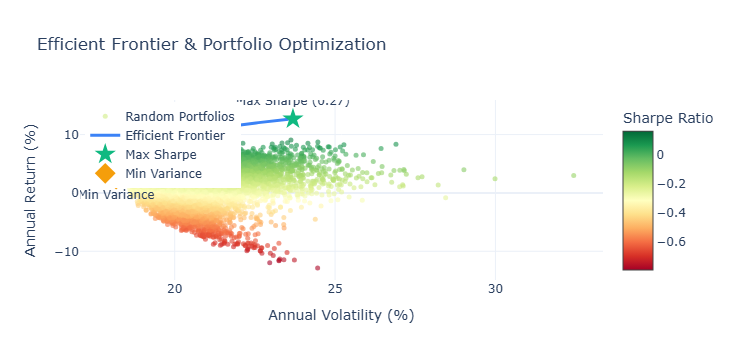

In [6]:
fig = plot_efficient_frontier(frontier, random_portfolios, max_sharpe, min_var, list(log_returns.columns))
fig.show()

### Understanding the Frontier
- The Efficient Frontier represents the set of optimal portfolios that offer the highest expected return for a defined level of risk.
- Portfolios below the frontier are suboptimal because they do not provide enough return for the level of risk they take.

## 5. Risk Metrics for Optimal Portfolio

In [7]:
weights_arr = np.array(list(max_sharpe['weights'].values()))

var_95  = portfolio_var(weights_arr, ef.mean_returns, ef.cov_matrix, confidence=0.95)
cvar_95 = portfolio_cvar(weights_arr, ef.mean_returns, ef.cov_matrix, confidence=0.95)
var_99  = portfolio_var(weights_arr, ef.mean_returns, ef.cov_matrix, confidence=0.99)
cvar_99 = portfolio_cvar(weights_arr, ef.mean_returns, ef.cov_matrix, confidence=0.99)

risk_table = pd.DataFrame({
    'Metric': ['VaR (95%)', 'CVaR (95%)', 'VaR (99%)', 'CVaR (99%)'],
    'Daily Loss (%)': [f'{v*100:.2f}%' for v in [var_95, cvar_95, var_99, cvar_99]],
    'Annual Loss (IDR, Rp 100jt)': [f'Rp {v*100_000_000:,.0f}' for v in [var_95, cvar_95, var_99, cvar_99]]
})
risk_table.set_index('Metric')

,Daily Loss (%),"Annual Loss (IDR, Rp 100jt)"
Metric,,
VaR (95%),2.40%,"Rp 2,404,154"
CVaR (95%),3.03%,"Rp 3,027,676"
VaR (99%),3.42%,"Rp 3,421,068"
CVaR (99%),3.93%,"Rp 3,926,718"


### Interpretation
For a Rp 100 million portfolio, a 95% Daily VaR of X% means that there is a 5% chance of losing more than Rp Y on any single trading day.